In [1]:
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import torch
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('../GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Initial Setup

In [2]:
RUN_ID = 'test2'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e1)

REF_VALUES = SR_lib.get_ref_values()

UNITS, UNIT_CONV = SR_lib.get_units_dict()

VARIABLES = ['R0','R1', 'C1', 'k', 'sdot', 'Ue']
# Optimization settings for PySR
SELECTION = "best"

if os.path.exists(f'saved_sr_models/{RUN_ID}'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')


Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


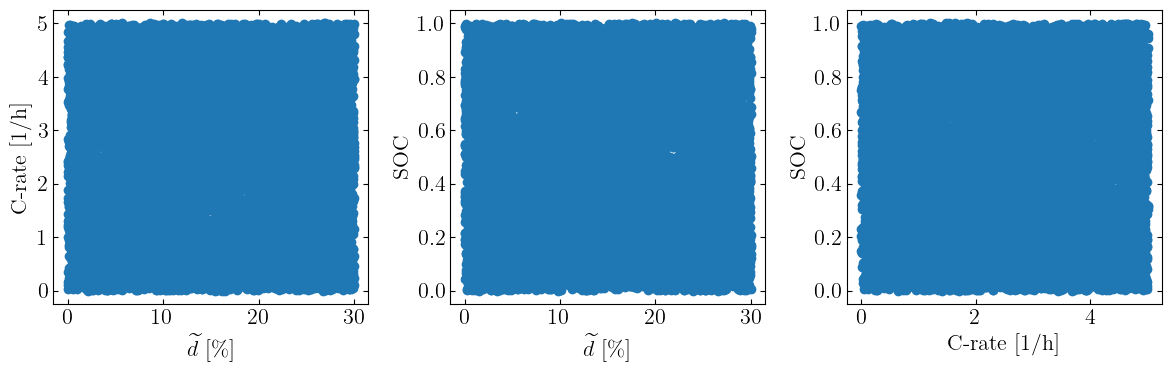

In [3]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('SR_samples.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('../data/polished_combo/combo_half.txt', delimiter=';')

f, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[0].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[0].set_ylabel('C-rate [1/h]')
ax[1].set_xlabel('C-rate [1/h]')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[1].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[1].set_ylabel('SOC ')
ax[2].plot(df['C_rate'],df['SOC'], 'o')
ax[2].set_xlabel('C-rate [1/h]')
ax[2].set_ylabel('SOC ')
plt.tight_layout()

#display(df)
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)


In [4]:

s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)

s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']].copy()
REF_VALUES['s'] = s_data['s'].max()

s_data['C'] = s_data['I'] * 3600 / Q0


s_data['s'] = s_data['s'] / REF_VALUES['s']

s_data['C'] = s_data['C'] / REF_VALUES['C']

s_data['u_per'] = s_data['u_per'] / REF_VALUES['d']

s_data['sdot'] = s_data['sdot'] / REF_VALUES['sdot']
s_data.describe()



,I,u_per,soc,s,sdot,C
count,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000
mean,6.959620,0.429038,0.544854,0.294561,0.869936,0.279603
std,6.807070,0.309418,0.257924,0.240674,1.009850,0.273474
min,0.000000,0.000000,0.024633,0.000000,0.003351,0.000000
25%,0.000000,0.176667,0.329973,0.093446,0.087223,0.000000
50%,4.480394,0.406667,0.548750,0.227796,0.599727,0.180000
75%,10.952074,0.686667,0.762836,0.459088,1.125820,0.440000
max,24.891078,0.990000,1.000000,1.000000,5.313158,1.000000


In [5]:
# Save reference values for simulating the observed outputs. 

save_refvalues = True
if save_refvalues:
    df_ref = pd.DataFrame(REF_VALUES, index=[0])
    df_existing = pd.read_csv("saved_sr_models/ref_values.csv")
    if RUN_ID in df_existing['run_id'].values:
        print(f'Run ID {RUN_ID} already exists in ref_values.csv. Did not save new reference values.')
    else:
        df_ref.to_csv(f'saved_sr_models/ref_values_{RUN_ID}.csv', index=False)
        df_ref['run_id'] = RUN_ID
        df_new = pd.DataFrame(df_ref, columns=df_existing.columns.values)
        df_combined = pd.concat([df_existing,df_new], ignore_index=True)
        df_combined.to_csv("saved_sr_models/ref_values.csv", index=False)

        #df_combined.to_excel("exp_log/Euler_exps.xlsx", index=False)

In [6]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


In [7]:
samples = generate_data(df.values)

100%|██████████| 10000/10000 [00:09<00:00, 1097.11it/s]


In [8]:
VARIABLES = ['R0','R1', 'C1', 'k']
N_VAR = len(VARIABLES)
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['d']
data['C'] =  data['C'] / REF_VALUES['C']

data.describe() 

,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.823645,5.678430,9.447663,2.887359,0.499987,0.499977,0.499957
std,0.149276,10.257809,3.838857,0.377416,0.288700,0.288720,0.288703
min,0.400871,0.188216,0.123883,2.239312,0.000000,0.000000,0.000000
25%,0.744825,0.592013,10.566363,2.558353,0.249950,0.250008,0.250000
50%,0.809587,0.721194,11.240972,2.840583,0.500000,0.500017,0.500000
75%,0.877739,1.949865,11.378365,3.192075,0.750000,0.749958,0.750000
max,1.482466,28.958312,13.489980,3.777907,1.000000,0.999900,1.000000


# Importing data

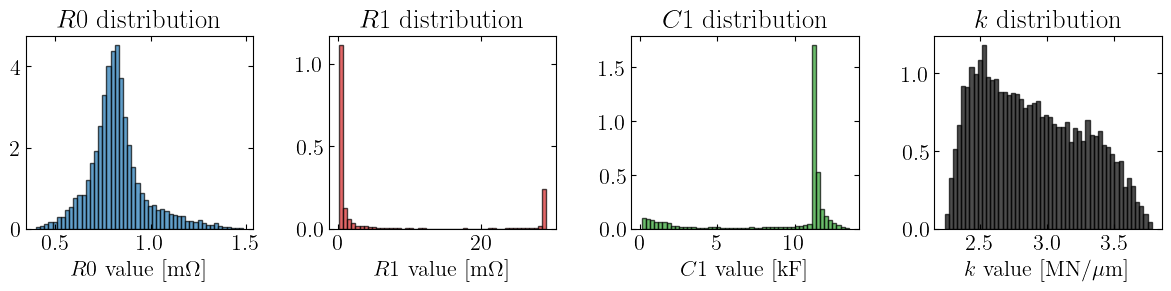

In [9]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [10]:
def get_XY(d_frame, s_frame = None):

    if s_frame is not None:
        for i in range(1,10):
            inds = np.arange(0,len(s_frame)) % i == 0
            if inds.sum() < 1e4:
                break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values 
    Y_R1 = d_frame['R1'].values 
    Y_C1 = d_frame['C1'].values 
    Y_k  = d_frame['k'].values  
    if s_frame is not None:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
        Y_s = Y_s[inds]
        X_s = X_s[inds]
    else: 
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

In [11]:
split_train = int(len(data) * 0.99)
s_split_train = int(len(s_data) * 0.99)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = SR_lib.prepare_data(data_train)
    trajs_test  = SR_lib.prepare_data(data_test)
else:
    data_train  = data#[:split_train]
    data_test   = data#[split_train:]
    s_data_train = s_data#[:s_split_train]
    s_data_test = s_data#[s_split_train:]


X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    'sdot':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    'sdot':  Ys_test
}



# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.022280984
Equation: 0.8235564

Model 1: Complexity=3, Loss=0.021061784
Equation: sqrt(sqrt(soc))

Model 2: Complexity=4, Loss=0.0149950655
Equation: soc ^ soc

Model 3: Complexity=5, Loss=0.009725464
Equation: sqrt(0.42620063 + cube(soc))

Model 4: Complexity=6, Loss=0.006565816
Equation: sqrt(square(cube(soc)) + 0.55214345)

Model 5: Complexity=9, Loss=0.0065656905
Equation: sqrt(0.55250376 + cube(square(soc))) ^ 0.9941906

Model 6: Complexity=11, Loss=0.0065235887
Equation: (((soc ^ 2.2153187) ^ 2.21531) / 2.0485573) + 0.7439079

Model 7: Complexity=13, Loss=0.004219288
Equation: sqrt(square(soc / 1.217124) + (((C + d) * -0.3181102) + 0.797051))

Model 8: Complexity=18, Loss=0.0037144432
Equation: sqrt(sqrt(square((cube(soc - 0.08864234) + sqrt((1.7067318 - (d * C)) - -0.03137418)) - 0.73836094)))

Model 9: Complexity=19, Loss=0.002773898
Equation: sqrt((0.98914915 / ((cube(d) + exp(soc)) + C)) + square((soc * (soc / 1.0665052)) + 0.13148792))

Model 10:

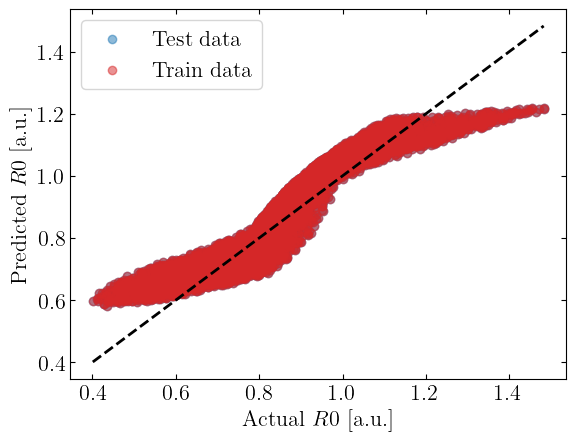

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt((0.937641935547994*soc**2 + 0.13148792)**2 + 0.98914915/(C + d**3 + exp(soc)))
Loss: 0.002773898
Best model complexity: 19


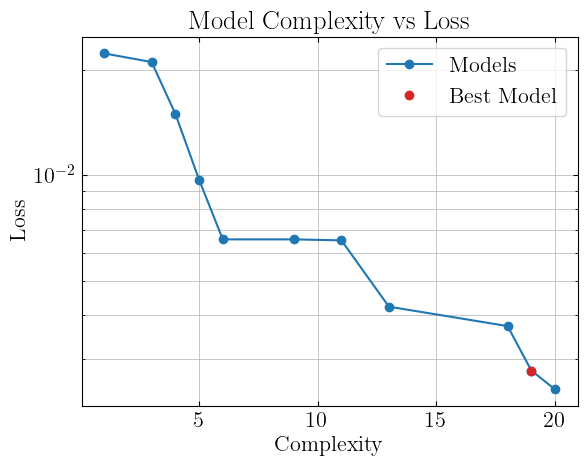

In [12]:
import_reload()
model_R0 = SR_lib.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
SR_lib.print_models(df_model_R0)
import_reload() 
SR_lib.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
SR_lib.print_best_model(model_R0)
SR_lib.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=105.21213
Equation: 5.6804104

Model 1: Complexity=3, Loss=97.52407
Equation: C * 11.163552

Model 2: Complexity=4, Loss=71.98367
Equation: cube(2.3570428 - soc)

Model 3: Complexity=5, Loss=41.822964
Equation: square(cube(1.7268349 - soc))

Model 4: Complexity=6, Loss=41.545277
Equation: square(exp(square(1.310477 - soc)))

Model 5: Complexity=7, Loss=41.232487
Equation: square(cube(soc - 1.71735)) + C

Model 6: Complexity=8, Loss=26.359962
Equation: (C * (0.01097757 ^ soc)) * 56.05982

Model 7: Complexity=9, Loss=24.888441
Equation: (0.00473853 ^ soc) * (sqrt(C) * 44.416985)

Model 8: Complexity=10, Loss=18.701109
Equation: square(cube((C * 0.62273335) ^ soc) * 6.0291247)

Model 9: Complexity=15, Loss=18.197956
Equation: square(square(exp(square(sqrt((C * 0.6114562) ^ soc)))) + -2.3958) / 0.6802206

Model 10: Complexity=16, Loss=15.100126
Equation: square(square(exp((square(0.30153653 ^ soc) * square(C)) ^ soc)) / 1.2335589)

Model 11: Complexity=17, Loss=

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(4*(0.12047721**soc*C*1.6937182)**(3*soc))/1.9454979
Loss: 11.612992
Best model complexity: 17


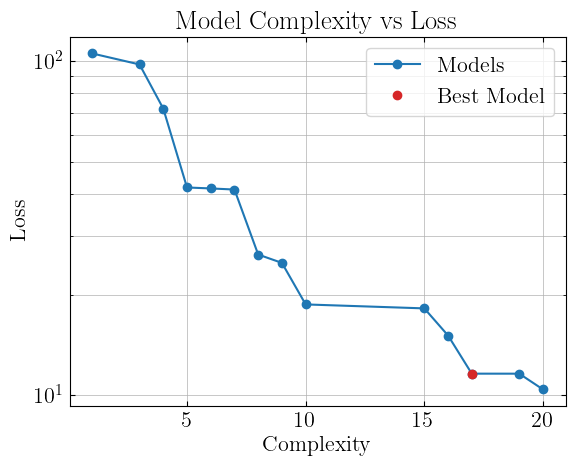

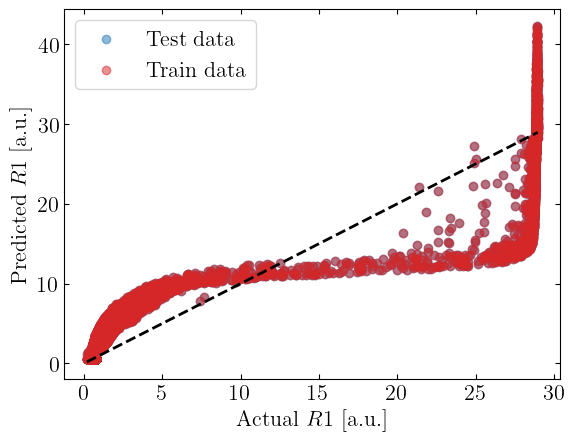

In [13]:
import_reload()
model_R1 = SR_lib.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
SR_lib.print_models(df_model_R1)
SR_lib.print_best_model(model_R1)
SR_lib.pareto_plot(model_R1)
SR_lib.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=14.735356
Equation: 9.44551

Model 1: Complexity=3, Loss=13.298544
Equation: soc + 8.97055

Model 2: Complexity=4, Loss=9.362873
Equation: exp(soc + 1.6950382)

Model 3: Complexity=5, Loss=7.5533733
Equation: exp(exp(sqrt(sqrt(soc))))

Model 4: Complexity=6, Loss=5.6158347
Equation: (sqrt(soc) * 12.543354) + 1.0861944

Model 5: Complexity=7, Loss=3.317408
Equation: (-2.248187 / (soc + 0.12593615)) + 14.346146

Model 6: Complexity=9, Loss=3.1810277
Equation: ((-2.324618 / (soc + 0.12710041)) + 15.052586) - C

Model 7: Complexity=10, Loss=3.180251
Equation: (16.254284 - exp(C)) + (-2.312072 / (soc + 0.12851954))

Model 8: Complexity=11, Loss=2.6969352
Equation: (-5.9262247 / (soc + 0.21246547)) + ((soc / -0.12822664) + 23.86959)

Model 9: Complexity=13, Loss=2.4934049
Equation: ((-9.770826 / (soc + 0.29818)) + 30.090647) + ((soc * -11.126197) - 0.7172911)

Model 10: Complexity=15, Loss=2.4876993
Equation: (soc + 23.65555) + ((-8.472072 / (soc + 0.32480967)) - 

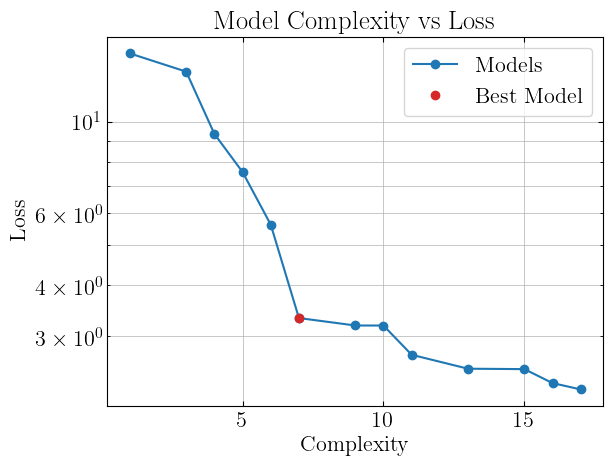

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 14.346146 - 2.248187/(soc + 0.12593615)
Loss: 3.317408
Best model complexity: 7


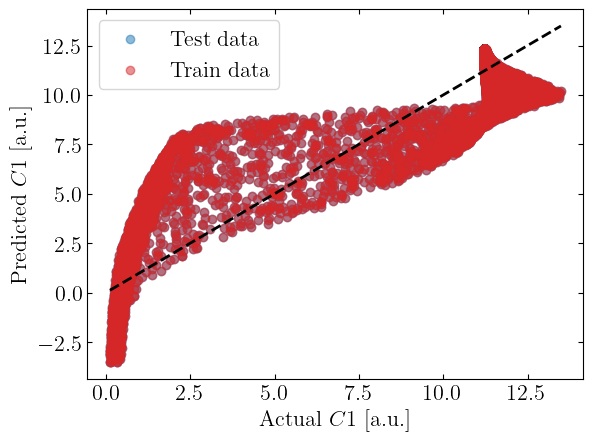

In [14]:
import_reload()
model_C1 = SR_lib.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
SR_lib.print_models(df_model_C1)
SR_lib.pareto_plot(model_C1)
SR_lib.print_best_model(model_C1)
SR_lib.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.14242895
Equation: 2.8872387

Model 1: Complexity=3, Loss=0.015178867
Equation: d + 2.3871427

Model 2: Complexity=4, Loss=0.0150002595
Equation: square(d) + 2.5500839

Model 3: Complexity=5, Loss=0.009399205
Equation: (d * 1.2610661) + 2.2565346

Model 4: Complexity=6, Loss=0.007937305
Equation: (2.2936795 ^ d) - -1.326919

Model 5: Complexity=7, Loss=0.007826172
Equation: d + (2.5397341 - (0.3039575 * soc))

Model 6: Complexity=9, Loss=0.0041977693
Equation: (d - ((soc - d) * 0.2880263)) + 2.4358768

Model 7: Complexity=10, Loss=0.0003825184
Equation: (d - ((soc - cube(d)) * 0.30318734)) + 2.4619358

Model 8: Complexity=13, Loss=5.0318933e-05
Equation: (exp((d / 1.366969) + (0.8301844 ^ soc)) * 0.47674537) - -1.1349325

Model 9: Complexity=16, Loss=3.1989115e-05
Equation: (exp(((0.8941199 ^ soc) + (d / 1.7048751)) * 1.3532652) - d) ^ 0.66190135



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (-d + exp((0.8941199**soc + d/1.7048751)*1.3532652))**0.66190135
Loss: 3.1989115e-05
Best model complexity: 16


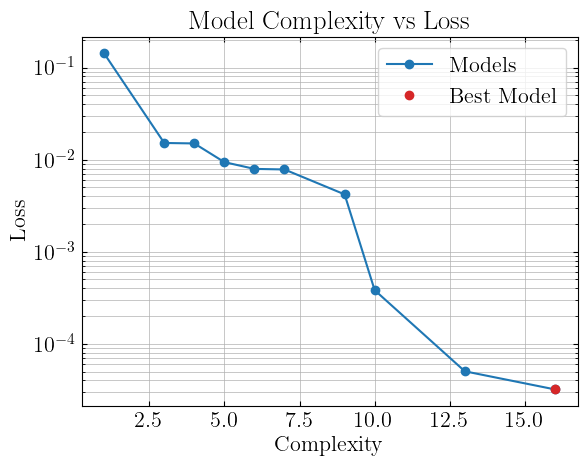

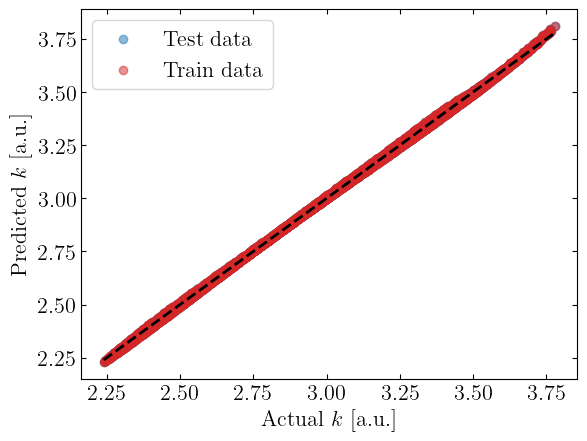

In [15]:
import_reload()
model_k = SR_lib.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
SR_lib.print_models(df_model_k)
SR_lib.print_best_model(model_k)
SR_lib.pareto_plot(model_k)
SR_lib.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(i,d,\mathrm{SOC},s)$

Variable names for element sdot: ['C', 'd', 'soc', 's']
Running symbolic regression for element sdot with run_id sdot_test2...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.0207566
Equation: 0.8668193

Model 1: Complexity=2, Loss=0.7823736
Equation: exp(C)

Model 2: Complexity=3, Loss=0.38231924
Equation: C * 3.0190861

Model 3: Complexity=4, Loss=0.36027333
Equation: exp(C) - d

Model 4: Complexity=5, Loss=0.17574312
Equation: C / (0.17068087 + d)

Model 5: Complexity=6, Loss=0.0147764
Equation: C / (cube(d) + 0.20849596)

Model 6: Complexity=8, Loss=0.010065588
Equation: C / (cube(d - -0.04930165) + 0.20346119)

Model 7: Complexity=9, Loss=0.008849822
Equation: (((d - 0.86699843) * C) / -0.20563312) + C

Model 8: Complexity=11, Loss=0.008742482
Equation: C * (square(square(sqrt(sqrt(1.0716563 - d)))) * 4.8257837)

Model 9: Complexity=13, Loss=0.008405801
Equation: (square(sqrt(1.0484186 - sqrt(square(d)))) * (C * 4.93855)) - -0.028347857

Model 10: Complexity=20, Loss=0.008277875
Equation: square(cube((((C * 2.3659697) * (C * ((0.014892186 ^ d) ^ d))) ^ 0.10565311) - -0.21213843))

Model 11: Complexity=23, Loss=0.0065778294

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: C*(d - 1*0.86699843)/(-0.20563312) + C
Loss: 0.008849822
Best model complexity: 9


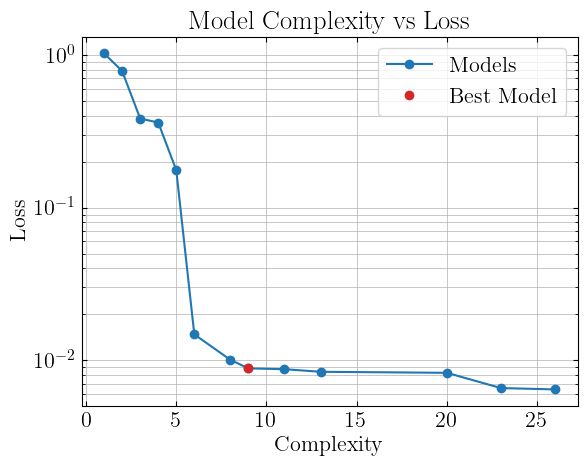

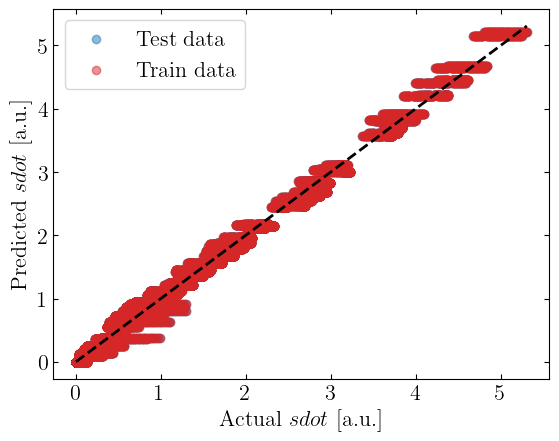

In [16]:
import_reload()
model_s = SR_lib.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f'sdot_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'sdot')
df_model_s = model_s.equations_
SR_lib.print_models(df_model_s)
SR_lib.print_best_model(model_s, s = True)
SR_lib.pareto_plot(model_s)
SR_lib.parity_plot('sdot',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [17]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [18]:
if SAVE:
    SR_lib.save_expressions(df_model_R0, f'R0_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_s, f'sdot_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_s.get_best(), f'sdot_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_k,  f'k_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_R1, f'R1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_C1, f'C1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}', run_id = RUN_ID)